This is a notebook to setup the environment, explore an upper level ontology called SULO (Simplified Upper Level Ontology), and perform some automated reasoning, query, and visualization.

# OWL Ontologies

The **Web Ontology Language (OWL)** is a formal language for representing knowledge about a domain in a way that both humans and machines can understand. It is a core technology of the Semantic Web, designed to describe what exists in a domain, how things relate, and to enable automated reasoning over that knowledge.

An **OWL ontology** is a formal, machine-readable description of a domain of knowledge, written in OWL, that defines:

* what kinds of things exist (`Class`)
* which specific things exist (`Individual`)
* how they are related (`ObjectProperty`)
* and what attributes they have (`DataProperty`)

together with logical rules that constrain and structure this knowledge.


**Reference material** — two companion notebooks are available alongside this tutorial:

- [OWL Primer Reference](00-OWL-primer-reference.ipynb) — a concise reference card of OWL constructs (classes, properties, axiom types, restrictions) used throughout the tutorial.
- [owlready2 Primer](00-owlready2-primer.ipynb) — a hands-on introduction to the owlready2 Python library: loading ontologies, defining classes and properties, running the reasoner, and querying results.

Refer to these at any point if you want a deeper look at a construct before continuing.

Now let's load the SULO ontology from its location on the web, save it to a local directory "dist/", and print out its base IRI.

In [2]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
from graphviz import Digraph

# Load SULO (remote import)
sulo = get_ontology("https://w3id.org/sulo/sulo.owl").load()  # RDF/XML
print("Loaded SULO:", sulo.base_iri)

import os
os.makedirs("dist", exist_ok=True)
sulo.save("dist/sulo.owl", format="rdfxml")  # Save a local copy in RDF/XML format


Loaded SULO: https://w3id.org/sulo/


## Why SULO?

Rather than building our pizza ontology from scratch on top of `owl:Thing`, we import **SULO** — the Simplified Upper Level Ontology. SULO provides a small set of carefully designed top-level classes (`SpatialObject`, `Process`, `Quality`, `Quantity`, `Role`, …) and properties (`hasPart`, `hasFeature`, `hasParticipant`, …) that carry precise, reusable semantics.

By grounding our pizza classes in SULO, we inherit those semantics for free. For example, declaring `FoodMaterial` as a subclass of `sulo:SpatialObject` immediately tells any consumer of our ontology and the reasoner that food materials are the kind of thing that persists through time, can gain and lose parts, and is wholly present at each moment of its existence.

Let's inspect what SULO gives us before we start building.

In [3]:
print("SULO base IRI:", sulo.base_iri)
print("SULO classes:", [c.name for c in sulo.classes()])
print("\nSULO object properties:", [p.name for p in sulo.object_properties()])

comment = sulo.Object.comment
print("\nObject definition:", comment[0] if comment else "(no comment)")

comment = sulo.SpatialObject.comment
print("\nSpatialObject definition:", comment[0] if comment else "(no comment)")
print("SpatialObject is_a:", sulo.SpatialObject.is_a)



SULO base IRI: https://w3id.org/sulo/
SULO classes: ['Process', 'Collection', 'Role', 'Feature', 'InformationObject', 'TimeInterval', 'Time', 'SpatialObject', 'Object', 'Capability', 'Quality', 'Quantity', 'Unit', 'TimeInstant', 'EndTime', 'StartTime', 'Duration']

SULO object properties: ['isItemIn', 'isPartOf', 'isIn', 'hasPart', 'contains', 'atTime', 'isTimeOf', 'isFeatureOf', 'hasItem', 'hasParticipant', 'precedes', 'isReferredToIn', 'refersTo', 'hasDirectPart', 'isDirectPartOf', 'isParticipantIn', 'isPrecededBy', 'hasFeature']

Object definition: An object is an entity that maintains its identity through time, and does not have processes as its parts.

SpatialObject definition: A spatial object is an object that occupies space
SpatialObject is_a: [sulo.Object, sulo.hasPart.only(sulo.SpatialObject)]


Let's examine the class hierarchy and labels:


In [4]:
from IPython.display import display, Markdown

# Class tree: roots are direct subclasses of owl:Thing
roots = sorted([c for c in sulo.classes() if Thing in c.is_a], key=lambda c: c.name)
lines, visited = [], set()
for root in roots:
    build_tree(root, lambda c: c.subclasses(), visited=visited, lines=lines)
display(Markdown("\n".join(lines)))


- **Object**: An object is an entity that maintains its identity through time, and does not have processes as its parts.
  - **Feature**: A feature is any characteristic that stems from the intrisinc structure and/or context
    - **Capability**: A capability is a feature that describes what an entity is able to do, under some set of circumstances.
    - **InformationObject** — information object: an information object is a feature that represents, is about, or encodes some information.
      - **Collection**: A collection is an information object for which there may be zero or more items.
      - **Quantity**: A quantity is an information object that represents the magnitude (and unit) of an object or process.
        - **Time**: time is a quantity pertaining to the duration of some interval of time or a particular instant of time (against some frame of reference).
          - **Duration**: Duration is a temporal quantity that represents the extent or (non-negative) amount of time that elapses between two temporal points, typically the start and end of a time interval.
          - **TimeInstant** — time instant: time instant is a quantity of time a particular moment in time.
            - **EndTime** — end time: an end time is a time instant at the end of a process/time interval.
            - **StartTime** — start time: a start time is a time instant at the beginning of a process/time interval.
          - **TimeInterval** — time interval: A time interval is a quantity for a continuous and bounded extent of time, characterized by a start time and an end time.
        - **Unit**: a unit is a standardized quantity that is used as a reference for a particular quantity.
    - **Quality**: A quality is a feature that is intrinsically associated with its bearer (or its parts).
    - **Role**: A role is a feature that describes a context-dependent behaviour.
  - **SpatialObject** — spatial object: A spatial object is an object that occupies space
- **Process**: a process is a entity that unfolds in time, has temporal parts, and has objects that participate in the process.

SULO Class hierarchy


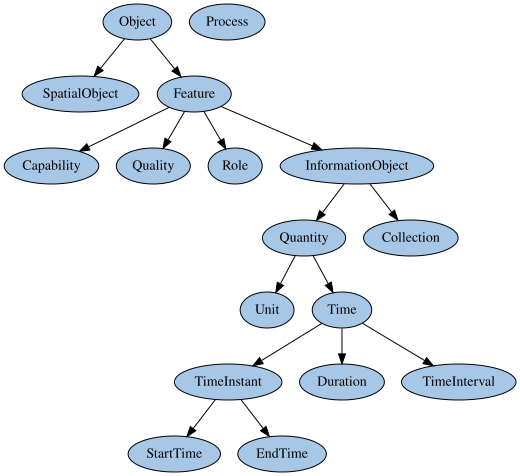

In [5]:
sulo_class_tree = get_color_tree(sulo)
print("SULO Class hierarchy")
display(sulo_class_tree)  # Class hierarchy


In [6]:
# Build parent→children map for the sub-property hierarchy
subprops = {}
for p in sulo.object_properties():
    for parent in p.is_a:
        if isinstance(parent, type) and issubclass(parent, ObjectProperty) and parent is not ObjectProperty:
            subprops.setdefault(parent, []).append(p)

# Root properties: no other ObjectProperty in is_a
prop_roots = sorted(
    [p for p in sulo.object_properties()
     if not any(isinstance(x, type) and issubclass(x, ObjectProperty) and x is not ObjectProperty
                for x in p.is_a)],
    key=lambda p: p.name
)

lines, visited = [], set()
for root in prop_roots:
    build_tree(root, lambda p: subprops.get(p, []), visited=visited, lines=lines)
display(Markdown("\n".join(lines)))


- **atTime** — at time: a relation between any thing and the time in which it occurs at.
- **contains**: A binary relation where the subject entity includes the object entity within its spatial, temporal, structural, or conceptual extent.
  - **hasPart** — has part: has part is a transitive, reflexive and antisymmetric relation between a whole and itself or a whole and its part.
    - **hasDirectPart** — has direct part: has direct part is a non-transitive parthood relation that can be used to specify cardinality constraints between a whole and its parts.
- **hasFeature** — has feature: has feature is a relation between a thing and an internal, contextual, or externally attributed characteristic.
- **hasItem** — has item: has item is a relation between a collection and an item contained therein.
- **hasParticipant** — has participant: has participant is a relation that describes the participation of a (non-process) thing in a process.
- **isFeatureOf** — is feature of: is feature of is a relation between an internal, contextual, or externally attributed characteristic and some Thing.
- **isParticipantIn** — is participant in: is participant in is a relation to relate an object and the process in which it participates.
- **isPrecededBy** — is preceded by: A relation in which one process occurs after to another process.
- **isReferredToIn** — is referred to in: is referred to in is relation between an object that is the subject of an information object.
- **isTimeOf** — is time of: a relation between a time and an object that occurs within it.
- **precedes**: A relation in which one process occurs prior to another process.
- **refersTo** — refers to: refers to is a binary relation between an information object and any other object that it mentions, describes, represents, encodes, or otherwise provides information about.

SULO Property map


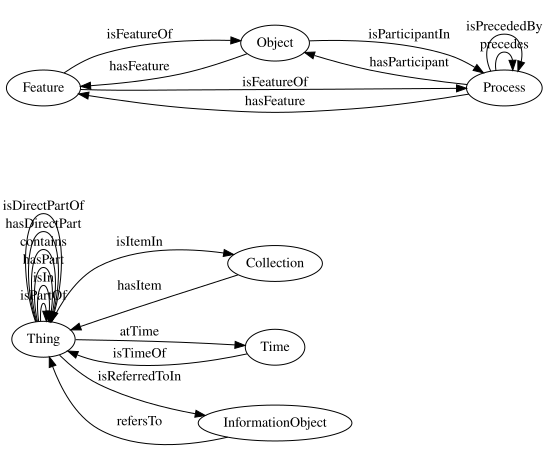

In [7]:
print("SULO Property map")
sulo_property_map = onto_property_map(sulo)
display(sulo_property_map)    # Property domain-range map


In [8]:
result = safe_call_reasoner(sulo)

print("SULO ontology after reasoning has", len(list(sulo.classes())), "classes")
print("SULO ontology after reasoning has", len(list(sulo.object_properties())), "object properties")
print("SULO ontology after reasoning has", len(list(sulo.data_properties())), "data properties")
print("SULO ontology after reasoning has", len(list(sulo.individuals())), "individuals")
print("SULO ontology has", len(result["inconsistent"]), "inconsistent classes")
for ic in result["inconsistent"]:
    print(" -", ic)

SULO ontology after reasoning has 17 classes
SULO ontology after reasoning has 18 object properties
SULO ontology after reasoning has 1 data properties
SULO ontology after reasoning has 0 individuals
SULO ontology has 0 inconsistent classes


In [9]:
# get the english label for quantity
sulo.Quantity.label.en

['quantity']

In [10]:
# get the english definition for Quantity
sulo.Quantity.comment.en

['A quantity is an information object that represents the magnitude (and unit) of an object or process.']

In [10]:
# query the SULO ontology for all subclasses of Quantity, excluding Quantity itself
print("SULO Quantity descendents:")
for cls in sulo.Quantity.descendants():
    if cls is not sulo.Quantity:
        print(" -", cls.name)

SULO Quantity descendents:
 - Time
 - StartTime
 - Duration
 - TimeInstant
 - TimeInterval
 - Unit
 - EndTime


In [11]:
# get the ancestors of sulo.Quantity, excluding Quantity
print("SULO Quantity ancestors:")
for anc in sulo.Quantity.ancestors():
    if anc is not sulo.Quantity:
        print(" -", anc.name)

SULO Quantity ancestors:
 - InformationObject
 - Thing
 - Object
 - Feature
